# **Analysis of Course and Instructors Rating Dataset for College Programs**

This dataset contains course section–level academic program data spanning two academic years and eight academic terms. Each observation represents a unique course section delivered in a specific term (course_section_id), with linked information on instructor attributes, course structure, enrollment composition, scheduling, and student evaluation responses. Instructor-related variables include identifiers, academic division, teaching status (full-time or part-time), and indicators for new faculty. Course-related variables describe course number, section, credits, course type (core or elective), and whether the course was newly introduced in the term. Operational metrics include enrollment capacity, actual enrollment by student level, waitlist counts, response rates, classroom location, meeting days, and instructional hours. The dataset also includes multiple student evaluation dimensions (Q1–Q17, workload, pacing, course value, and recommendation) capturing student perceptions of engagement, instructional clarity, inclusiveness, and overall course experience. The primary modeling outcome is the instructor rating score (Professor_Score), measured on a continuous 1–5 scale and treated as a supervised regression target.


**NOTE:**

*Due to privacy considerations, student, course and instructor data was anonymized. However, the integrity between the student, course and instructor relationships was maintained in the dataset.*

---

**Dataset Description**

2,208 records, each representing a course section taught in a specific term
53 variables spanning:

- Instructor identifiers & attributes (e.g., Professor_ID, Professor_Division, Professor_Teaching_Status, New_Professor)
- Course attributes (e.g., Course_Number, Course_Type, Course_Credits, Course_Division, New_Course)
- Term/time fields (e.g., Course_Year, Course_Term, Academic_Year, Term_Number)
- Enrollment composition and capacity (e.g., Enrollment_Total, Enrollment_MS, Enrollment_PhD, Course_Capacity, Waitlist)
- Scheduling/location (e.g., Classroom, days, Class_Time, Hours)
- Student evaluation dimensions (Q1–Q17 + workload/pace/value/Recommend items)

**Target candidate:** Professor_Score (continuous; ranges from 1.0 to 5.0)




In [1]:
#@title Import Academic Program Data

import pandas as pd
import numpy as np

# Read Program Data CSV file
url = 'https://raw.githubusercontent.com/johnnydrodriguez/data622/refs/heads/main/program_data.csv'
programdata_df = pd.read_csv(url, delimiter=',')

print("Shape:", programdata_df.shape)
display(programdata_df.head(3))


Shape: (2208, 53)


,course_section_id,New_Professor,Professor_ID,Professor_Division,Professor_Teaching_Status,Professor_Score,Course_Score,Co_Professor,Professor_Enrollments,Course_Number,...,Q8_Stu_Recommend_Score,Q10_Average_workload_rating,Q11_Course_Pace_Score,Q12_Course_Content_Score,Q13_Instr_Attunement_Score,Q14_Instr_Clarity_Score,Q15_Instr_Expectations_Score,Q16_Instr_Feedback_Score,Q17_Instr_Inclusiveness_Score,Course_Teaching_Assistant
0,214083,No,b3a47ed1,QAHF,Full Time,4.830000,4.558974,No,1,C78116,...,4.714285,3.833333,3.523809,4.452380,0.0,0.0,0.0,0.0,0.0,Yes
1,214084,No,b3a47ed1,QAHF,Full Time,4.865000,4.615789,No,1,C78116,...,4.690476,3.690476,3.619047,4.357142,0.0,0.0,0.0,0.0,0.0,Yes
2,214085,No,b3a47ed1,QAHF,Full Time,4.924528,4.792453,No,1,C78116,...,4.833333,3.907407,3.537037,4.425925,0.0,0.0,0.0,0.0,0.0,Yes


# **Problem Statement & Exploratory Data Analysis**

Student evaluations of instruction are a central input into academic quality assurance, faculty development, and instructional support processes. The objective of this analysis is to model instructor rating outcomes using course characteristics, instructor attributes, enrollment composition, scheduling factors, and student evaluation dimensions in order to support both explanatory insight and operational decision-making.

To address these complementary goals, we adopt a dual-modeling approach.

- First, we employ ElasticNet, a highly interpretable regression model to surface stable, directionally meaningful relationships between predictor variables and instructor rating scores. This model explains variance in instructor performance, identify key drivers of student ratings, and support transparent interpretation suitable for academic governance and faculty development.


- Second, we employ XGBoost, a high-performance predictive model to maximize accuracy by capturing nonlinear relationships and interaction effects across course, instructor, and term characteristics. This model is intended to support operational expectations enabling proactive review, targeted coaching, and instructional support interventions based on the predicted score.

The analysis seeks to balance explanatory value with practical utility.  However, since the data covers two academic years comprising eight academic terms, it is not intended to infer long-term trends; rather, it provides actionable insights and predictive guidance grounded in observed instructional and evaluation patterns.

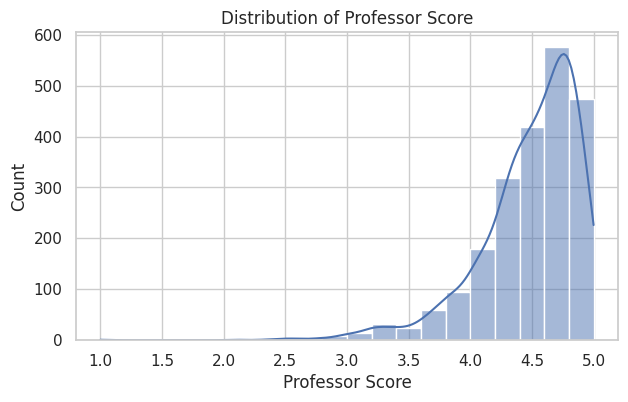

,Professor_Score
count,2208.000000
mean,4.480475
std,0.414259
min,1.000000
25%,4.298000
50%,4.571500
75%,4.777783
max,5.000000


In [2]:
#@title Target Variable Professor_Score Distribution

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(7,4))
sns.histplot(programdata_df["Professor_Score"], bins=20, kde=True)
plt.title("Distribution of Professor Score")
plt.xlabel("Professor Score")
plt.ylabel("Count")
plt.show()

programdata_df["Professor_Score"].describe()

Instructor rating scores are concentrated toward the upper end of the scale, with a mean above 4.4 and a relatively narrow spread. This right-skewed distribution suggests that most instructors are rated favorably, with relatively fewer low-scoring observations. As a result, predictive modeling will need to distinguish among subtle differences in performance rather than extreme outcomes. This also implies that error metrics such as MAE may be more interpretable than raw R² alone.

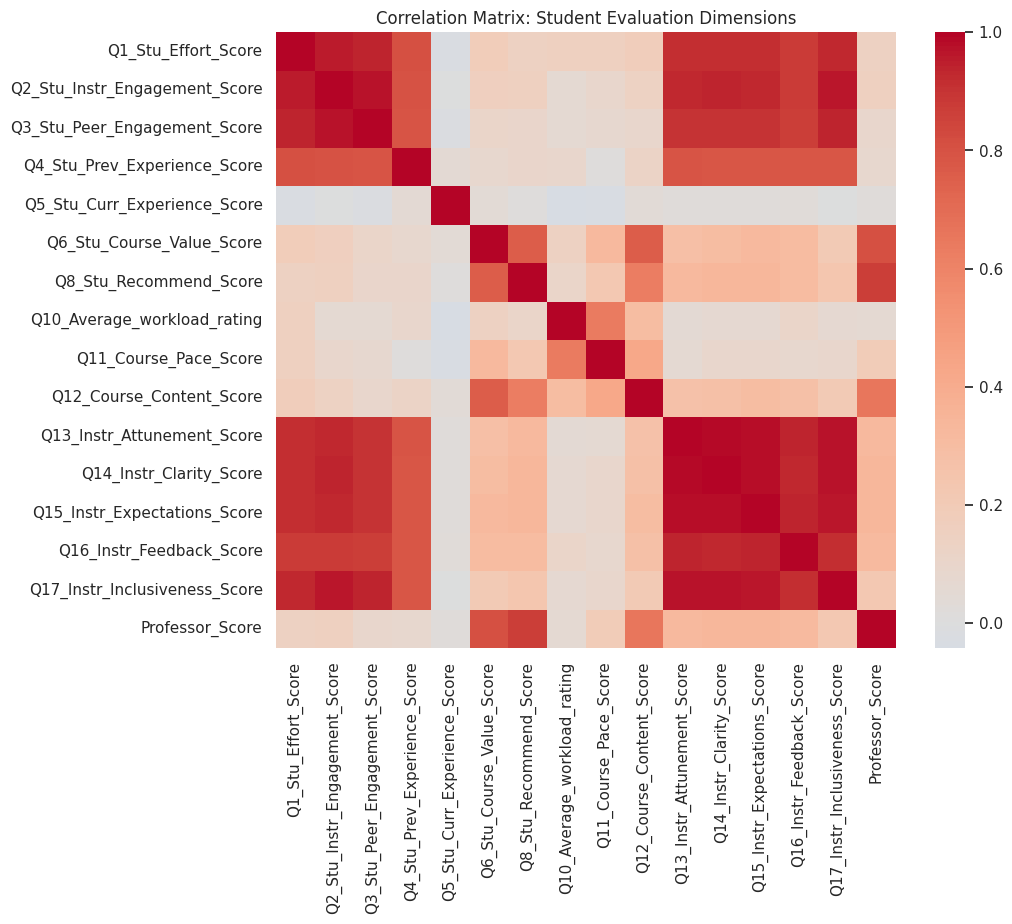

In [3]:
#@title Student Evaluation Score Correlations

eval_cols = [
    "Q1_Stu_Effort_Score",
    "Q2_Stu_Instr_Engagement_Score",
    "Q3_Stu_Peer_Engagement_Score",
    "Q4_Stu_Prev_Experience_Score",
    "Q5_Stu_Curr_Experience_Score",
    "Q6_Stu_Course_Value_Score",
    "Q8_Stu_Recommend_Score",
    "Q10_Average_workload_rating",
    "Q11_Course_Pace_Score",
    "Q12_Course_Content_Score",
    "Q13_Instr_Attunement_Score",
    "Q14_Instr_Clarity_Score",
    "Q15_Instr_Expectations_Score",
    "Q16_Instr_Feedback_Score",
    "Q17_Instr_Inclusiveness_Score"
]

corr_matrix = programdata_df[eval_cols + ["Professor_Score"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Student Evaluation Dimensions")
plt.show()

We assume that student ratings in general would be highly correlated with our target variable.  Significant correlation with the student rating scores and our target variable, Professor_Score indicates multicolinearity is present and needs to be accounted for in the model.

- Most student evaluation dimensions show moderate to strong positive correlations with one another.
- Items related to instructional clarity, engagement, responsiveness, and feedback exhibit particularly strong associations with Professor_Score.
- Q8_Stu_Recommend_Score is among the most highly correlated variables with the instructor score, reinforcing its conceptual association to the target.

In [4]:
#@title Check for Zero Values in Rating Scores

(programdata_df[eval_cols] == 0).mean().sort_values(ascending=False)

,0
Q3_Stu_Peer_Engagement_Score,0.036232
Q16_Instr_Feedback_Score,0.036232
Q1_Stu_Effort_Score,0.035779
Q4_Stu_Prev_Experience_Score,0.035779
Q14_Instr_Clarity_Score,0.035779
Q13_Instr_Attunement_Score,0.035779
Q2_Stu_Instr_Engagement_Score,0.035779
Q17_Instr_Inclusiveness_Score,0.035779
Q15_Instr_Expectations_Score,0.035779
Q11_Course_Pace_Score,0.000453


Several student evaluation variables contain a non-trivial proportion of zero values.  This suggests that zeros are being used as a placeholder for missing or non-applicable responses rather than true ratings.  We'll handle Zero values in each model:

- Zero values in student evaluation fields should be converted to NaN
- Missingness will be handled differently for Elastic Net (imputation required) and XGBoost (native handling)


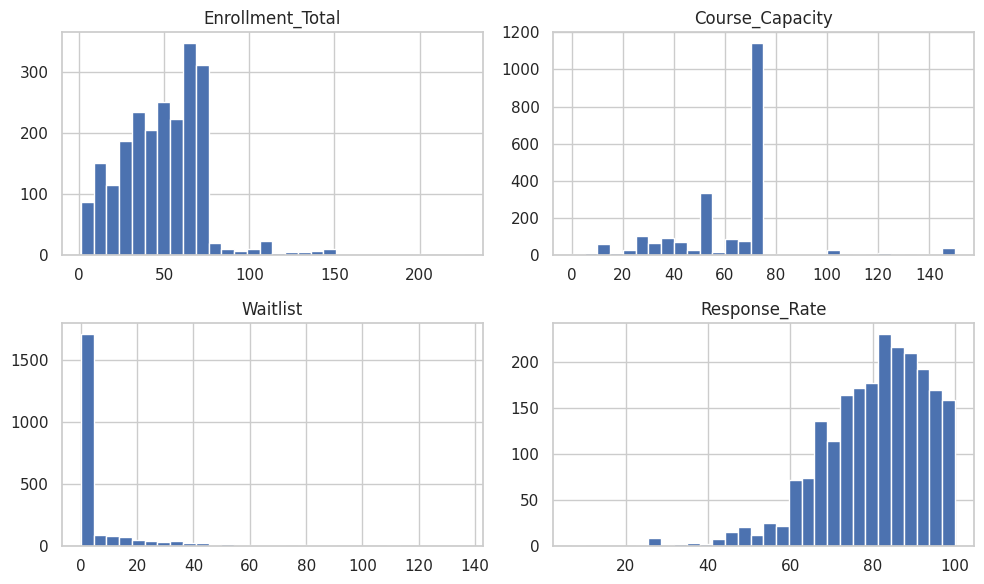

In [5]:
#@title Enrollment & Course Size Distributions

enroll_cols = [
    "Enrollment_Total",
    "Course_Capacity",
    "Waitlist",
    "Response_Rate"
]

programdata_df[enroll_cols].hist(bins=30, figsize=(10,6))
plt.tight_layout()
plt.show()

Enrollment and capacity variables display right-skewed distributions, with a small number of very large sections. This suggests that:

- Our ElasticNet models may benefit from scaling or transformation
- Our tree-based model will naturally handle skewness

In [6]:
#@title Cardinality Check

cat_cols = [
    "Professor_ID",
    "Professor_Division",
    "Course_Division",
    "Program_Degree",
    "Classroom",
    "days",
    "Course_Term"
]

programdata_df[cat_cols].nunique().sort_values(ascending=False)

,0
Professor_ID,432
days,52
Professor_Division,14
Course_Division,10
Program_Degree,3
Classroom,3
Course_Term,3


We check for cardinality in categorical variables to inform our model encoding.

- Elastic Net will require  encoding or exclusion of very high-cardinality identifiers
- XGBoost can absorb this complexity

# ElasticNet Processing


ElasticNet regression assumes:
- Numeric input features
- Comparable feature scales
- No implicit missing-value handling
- Linear, additive effects


To accomplish this:
- We prioritize stability over completeness by eliminating columns which do not fit the ElasticNet model
- We avoid high-cardinality variables that distort interpretation
- We remove sources of data leakage




In [7]:
#@title ElasticNet Model Data Cleanup

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

target = "Professor_Score"
df_en = programdata_df.copy()

#Convert prerequisites/corequisites to binary flags
# Assumption from you: blank = "No", non-blank = "Yes"
df_en["Prerequisites"] = df_en["Prerequisites"].notna().astype(int)
df_en["Corequisites"]  = df_en["Corequisites"].notna().astype(int)


# Recode survey zeros as missing
# Elastic Net needs explicit missing handling
survey_cols = [
    "Q1_Stu_Effort_Score",
    "Q2_Stu_Instr_Engagement_Score",
    "Q3_Stu_Peer_Engagement_Score",
    "Q4_Stu_Prev_Experience_Score",
    "Q5_Stu_Curr_Experience_Score",
    "Q6_Stu_Course_Value_Score",
    "Q8_Stu_Recommend_Score",
    "Q10_Average_workload_rating",
    "Q11_Course_Pace_Score",
    "Q12_Course_Content_Score",
    "Q13_Instr_Attunement_Score",
    "Q14_Instr_Clarity_Score",
    "Q15_Instr_Expectations_Score",
    "Q16_Instr_Feedback_Score",
    "Q17_Instr_Inclusiveness_Score"
]
df_en[survey_cols] = df_en[survey_cols].replace(0, np.nan)

# Convert Yes/No (and similar) to 1/0
def to_binary_flag(s: pd.Series) -> pd.Series:
    """
    Converts common flag encodings to 0/1:
    - Yes/No, Y/N, True/False, 1/0, '1'/'0'
    - blanks/NaN default to 0
    """
    s = s.astype(str).str.strip().str.lower()
    yes = {"yes", "y", "true", "t", "1"}
    no  = {"no", "n", "false", "f", "0", "nan", ""}

    return np.where(s.isin(yes), 1,
           np.where(s.isin(no), 0, np.nan)).astype("float")

# Ensure binary flag columns are numeric 0/1 (handles 'No'/'Yes')
binary_cols = [
    "New_Professor",
    "Co_Professor",
    "New_Course",
    "Separate_Evaluation",
    "Course_Teaching_Assistant"
]

for col in binary_cols:
    df_en[col] = to_binary_flag(df_en[col])

# If any unexpected values existed, they'll be NaN here.
df_en[binary_cols] = df_en[binary_cols].fillna(0).astype(int)


# Choose low-cardinality categorical variables for interpretability
categorical_cols = [
    "Professor_Division",
    "Professor_Teaching_Status",
    "Course_Division",
    "Course_Type",
    "Program_Degree",
    "Course_Term"
]


# Choose numeric predictors
numeric_cols = [
    "Course_Credits",
    "Course_Capacity",
    "Enrollment_Total",
    "Enrollment_Masters1",
    "Enrollment_Masters2",
    "Enrollment_MS",
    "Enrollment_PhD",
    "Enrollment_CrossReg_Other",
    "Response_Rate",
    "Waitlist",
    "Hours",
    "times_taught",
    "Prerequisites",
    "Corequisites"
]


# Assemble feature matrix X and target y
X_en = df_en[numeric_cols + binary_cols + survey_cols + categorical_cols].copy()
y_en = df_en[target].copy()

# Ensure numeric+survey columns are actually numeric (coerce bad strings to NaN)
for col in numeric_cols + survey_cols:
    X_en[col] = pd.to_numeric(X_en[col], errors="coerce")

# Impute missing values
# - Median for numeric
# - Most-frequent for categorical
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_en[numeric_cols + survey_cols] = num_imputer.fit_transform(X_en[numeric_cols + survey_cols])
X_en[categorical_cols] = cat_imputer.fit_transform(X_en[categorical_cols])

# One-hot encode categorical variables
X_en = pd.get_dummies(X_en, columns=categorical_cols, drop_first=True)

# Validate data
print("Elastic Net design matrix shape:", X_en.shape)
print("Any missing values remaining?", X_en.isna().any().any())

Elastic Net design matrix shape: (2208, 62)
Any missing values remaining? False


In [8]:
#@title Elastic Net: Standardize + Train/Test Split + Fit

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TERM-BASED  SPLIT
# Test set = last 2 unique terms in chronological order
term_key = df_en["Course_Year"].astype(int) * 100 + df_en["Term_Number"].astype(int)
last_terms = np.sort(term_key.unique())[-2:]
test_mask = term_key.isin(last_terms)

X_train, X_test = X_en.loc[~test_mask], X_en.loc[test_mask]
y_train, y_test = y_en.loc[~test_mask], y_en.loc[test_mask]

print(f"Split  TERM-BASED (test = last 2 terms: {last_terms.tolist()})")
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


# Standardize + ElasticNetCV
enet_pipe = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        alphas=np.logspace(-4, 1, 60),
        cv=5,
        random_state=42,
        max_iter=20000
    ))
])

enet_pipe.fit(X_train, y_train)

best_alpha = enet_pipe.named_steps["model"].alpha_
best_l1 = enet_pipe.named_steps["model"].l1_ratio_
print(f"Best Elastic Net params: alpha={best_alpha:.6f}, l1_ratio={best_l1}")


# Elastic Net evaluation & Metrics
y_pred_enet = enet_pipe.predict(X_test)
mae_enet  = mean_absolute_error(y_test, y_pred_enet)
rmse_enet = np.sqrt(mean_squared_error(y_test, y_pred_enet))
r2_enet   = r2_score(y_test, y_pred_enet)

print("Holdout performance (Elastic Net):")
print(f"  MAE : {mae_enet:.4f}")
print(f"  RMSE: {rmse_enet:.4f}")
print(f"  R^2 : {r2_enet:.4f}")

# Coefficient table for interpretation
coef = enet_pipe.named_steps["model"].coef_
coef_df = pd.DataFrame({
    "feature": X_en.columns,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

nonzero = coef_df[coef_df["coef"] != 0].copy()
print(f"Non-zero coefficients: {len(nonzero)} out of {X_en.shape[1]} features")

top_k = 15
print("\nTop positive drivers (largest + coefficients):")
display(nonzero.sort_values("coef", ascending=False).head(top_k)[["feature", "coef"]])

print("\nTop negative drivers (largest - coefficients):")
display(nonzero.sort_values("coef", ascending=True).head(top_k)[["feature", "coef"]])

print("\nOverall strongest drivers by absolute magnitude:")
display(coef_df.head(25)[["feature", "coef"]])

Split  TERM-BASED (test = last 2 terms: [222751, 222752])
Train shape: (1714, 62) Test shape: (494, 62)
Best Elastic Net params: alpha=0.004954, l1_ratio=0.3
Holdout performance (Elastic Net):
  MAE : 0.0924
  RMSE: 0.1230
  R^2 : 0.8647
Non-zero coefficients: 45 out of 62 features

Top positive drivers (largest + coefficients):


,feature,coef
25,Q8_Stu_Recommend_Score,0.220753
17,Separate_Evaluation,0.116165
24,Q6_Stu_Course_Value_Score,0.101108
30,Q14_Instr_Clarity_Score,0.082830
29,Q13_Instr_Attunement_Score,0.033666
6,Enrollment_PhD,0.033254
20,Q2_Stu_Instr_Engagement_Score,0.032662
28,Q12_Course_Content_Score,0.020185
2,Enrollment_Total,0.011087
45,Professor_Division_YICC,0.007752



Top negative drivers (largest - coefficients):


,feature,coef
15,Co_Professor,-0.119242
33,Q17_Instr_Inclusiveness_Score,-0.035770
21,Q3_Stu_Peer_Engagement_Score,-0.020699
57,Course_Type_Elective,-0.019103
26,Q10_Average_workload_rating,-0.015295
40,Professor_Division_QJJF,-0.011974
18,Course_Teaching_Assistant,-0.009652
1,Course_Capacity,-0.009650
27,Q11_Course_Pace_Score,-0.007094
44,Professor_Division_XLGG,-0.006585



Overall strongest drivers by absolute magnitude:


,feature,coef
25,Q8_Stu_Recommend_Score,0.220753
15,Co_Professor,-0.119242
17,Separate_Evaluation,0.116165
24,Q6_Stu_Course_Value_Score,0.101108
30,Q14_Instr_Clarity_Score,0.082830
33,Q17_Instr_Inclusiveness_Score,-0.035770
29,Q13_Instr_Attunement_Score,0.033666
6,Enrollment_PhD,0.033254
20,Q2_Stu_Instr_Engagement_Score,0.032662
21,Q3_Stu_Peer_Engagement_Score,-0.020699


# Elastic Net Results

**Strongest Positive Factors**

Three factors emerge as the most influential positive contributors to instructor ratings.

**1. Likelihood of recommending the instructor (Q8_Stu_Recommend_Score)**
This is the strongest positive driver by a wide margin. Higher student willingness to recommend the instructor is strongly associated with higher overall instructor ratings. This result is expected given the alignment between individal recommendations and teaching evaluations.

**2. Separate instructor evaluations (Separate_Evaluation)**
Courses in which instructors are evaluated separately (rather than jointly) show a meaningful positive association with instructor ratings. This suggests that clearer attribution of instructional responsibility may benefit individual ratings in settings where multiple instructors are present.

**3. Perceived course value and instructional clarity (Q6_Stu_Course_Value_Score, Q14_Instr_Clarity_Score)**
Student perceptions that the course is valuable and that instruction is delivered clearly are among the strongest drivers of instructor ratings. These factors rank near the top across positive coefficient lists,suggesting that ratings are driven less by structural features and more by how effectively course content is communicated.


**Strongest Negative Factors**

There is a small set of factors that are  associated with lower instructor ratings --  though their magnitudes are smaller than the strongest positive drivers.

**1. Co-taught courses (Co_Professor)**
The presence of co-instructors is the strongest negative factor.  This suggests that shared instructional responsibility may introduce coordination challenges or  ambiguity that depress student evaluations.

**2. Instructor inclusiveness and peer engagement (Q17_Instr_Inclusiveness_Score, Q3_Stu_Peer_Engagement_Score)**
Higher scores on inclusiveness and peer engagement are associated with modest negative coefficients. This likely reflects multicollinearity among correlated factors. Inclusiveness may be valued by students but not uniquely predictive once clarity, engagement, and course value are already accounted for.

**3. Course structure and workload factors (Course_Type_Elective, Q10_Average_workload_rating, Course_Capacity)**
Elective courses, higher perceived workload, and larger course capacity show small negative associations with instructor ratings. These effects suggest that instructional context and student expectations may influence evaluations in courses where workload intensity or class size affects instructor teaching quality.

# XG Boost Model

In [9]:
#@title Step 7 — XGBoost: Cleanup + TERM-BASED Train/Test Split + Fit

# Install XGBoost
!pip -q install xgboost

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

target = "Professor_Score"
df_xgb = programdata_df.copy()

# Prereq/Coreq: blank = No, non-blank = Yes
df_xgb["Prerequisites"] = df_xgb["Prerequisites"].notna().astype(int)
df_xgb["Corequisites"]  = df_xgb["Corequisites"].notna().astype(int)

# Recode survey zeros to NaN (treat as missing-code)
survey_cols = [
    "Q1_Stu_Effort_Score","Q2_Stu_Instr_Engagement_Score","Q3_Stu_Peer_Engagement_Score",
    "Q4_Stu_Prev_Experience_Score","Q5_Stu_Curr_Experience_Score","Q6_Stu_Course_Value_Score",
    "Q8_Stu_Recommend_Score","Q10_Average_workload_rating","Q11_Course_Pace_Score",
    "Q12_Course_Content_Score","Q13_Instr_Attunement_Score","Q14_Instr_Clarity_Score",
    "Q15_Instr_Expectations_Score","Q16_Instr_Feedback_Score","Q17_Instr_Inclusiveness_Score"
]
df_xgb[survey_cols] = df_xgb[survey_cols].replace(0, np.nan)

#  Cleaning for binary columns (handles 'Yes'/'No')
def to_binary_flag(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()
    yes = {"yes","y","true","t","1"}
    no  = {"no","n","false","f","0","nan",""}
    out = np.where(s.isin(yes), 1, np.where(s.isin(no), 0, np.nan))
    return pd.Series(out, index=series.index)

binary_cols = ["New_Professor","Co_Professor","New_Course","Separate_Evaluation","Course_Teaching_Assistant"]
for col in binary_cols:
    df_xgb[col] = to_binary_flag(df_xgb[col]).fillna(0).astype(int)


# TERM-BASED SPLIT
#  Test = last 2 unique terms in chronological order
term_key = df_xgb["Course_Year"].astype(int) * 100 + df_xgb["Term_Number"].astype(int)
last_terms = np.sort(term_key.unique())[-2:]
test_mask = term_key.isin(last_terms)


#  EXCLUDE pure identifiers that risk memorization
exclude_cols = [
    target,
    "course_section_id",
    "Professor_ID",
    "Course_Number",
    "Section_Number"
]

# Build X/y
X = df_xgb.drop(columns=[c for c in exclude_cols if c in df_xgb.columns]).copy()
y = df_xgb[target].copy()

X_train, X_test = X.loc[~test_mask], X.loc[test_mask]
y_train, y_test = y.loc[~test_mask], y.loc[test_mask]

print(f"Split method: TERM-BASED split (test = last 2 terms: {last_terms.tolist()})")
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


#  Impute numeric with median and categorical with most-frequent, then one-hot encode categoricals.
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)


# XGBRegressor Model (Default)
xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42
)

xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb_model)
])

# Fit
xgb_pipe.fit(X_train, y_train)


# Evaluation & Metrics
y_pred_xgb = xgb_pipe.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("Test  Performance (XGBoost):")
print(f"  MAE : {mae_xgb:.4f}")
print(f"  RMSE: {rmse_xgb:.4f}")
print(f"  R^2 : {r2_xgb:.4f}")


# Top feature importances
ohe = xgb_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_feature_names])

importances = xgb_pipe.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

print("\nTop 25 XGBoost feature importances:")
display(imp_df.head(10))


Split method: TERM-BASED split (test = last 2 terms: [222751, 222752])
Train shape: (1714, 48) Test shape: (494, 48)
Test  Performance (XGBoost):
  MAE : 0.0722
  RMSE: 0.1051
  R^2 : 0.9012

Top 25 XGBoost feature importances:


,feature,importance
67,Program_Degree_Masters1,0.164099
33,Q14_Instr_Clarity_Score,0.147496
28,Q8_Stu_Recommend_Score,0.125574
34,Q15_Instr_Expectations_Score,0.081628
66,Program_Degree_MSPHD,0.049761
27,Q6_Stu_Course_Value_Score,0.043774
15,Enrollment_PhD,0.039432
32,Q13_Instr_Attunement_Score,0.026434
1,Course_Score,0.021340
62,Course_Division_WIRK,0.018579


**Most Influential Predictive Factors**

**1. Program degree (Program_Degree_Masters1, Program_Degree_MSPHD)**
Program-level degree emerges as the most influential predictor in the XGBoost model. This indicates that instructor rating expectations differ  across academic program types, likely reflecting variation in student expectations, course rigor, cohort composition, and evaluative norms.

**2. Instructional clarity and expectation setting (Q14_Instr_Clarity_Score, Q15_Instr_Expectations_Score)**
Instructional clarity and clear communication of expectations rank among the strongest  predictors. This reinforces the ElasticNet findings while also suggesting nonlinear effects across these predictors.

**3. Student recommendation and perceived course value (Q8_Stu_Recommend_Score, Q6_Stu_Course_Value_Score)**
Student willingness to recommend the instructor and perceptions of course value remain highly predictive. In the XGBoost model, these variables likely interact with program context and course structure, amplifying their predictive power.

# Results Comparison

In [10]:
#@title Model Performance Comparison Table (Elastic Net vs XGBoost)

# Build comparison table
metrics_df = pd.DataFrame({
    "Model": ["Elastic Net (Interpretable)", "XGBoost (Predictive)"],
    "MAE":   [mae_enet, mae_xgb],
    "RMSE":  [rmse_enet, rmse_xgb],
    "R²":    [r2_enet, r2_xgb]
}).round(4)

display(metrics_df)

,Model,MAE,RMSE,R²
0,Elastic Net (Interpretable),0.0924,0.1230,0.8647
1,XGBoost (Predictive),0.0722,0.1051,0.9012


**ElasticNet Results**

The Elastic Net model is optimized for interpretability; it achieves a mean absolute error (MAE) of 0.092, a root mean squared error (RMSE) of 0.123, and an R² of 0.865 on the term-based test split set. These results indicate that a substantial proportion of the variance in instructor rating scores can be explained through a linear combination of course characteristics, instructor attributes, enrollment composition, and student evaluation dimensions. While predictive accuracy is not maximized, the model provides stable interpretable coefficients that support substantive inference about which factors are associated with higher or lower instructor ratings.

**XGBoost Results**

The XGBoost model is optimized for predictive accuracy; it demonstrates materially stronger performance, with an MAE of 0.072, an RMSE of 0.105, and an R² of 0.901. This improvement reflects XGBoost’s ability to capture nonlinear relationships and interaction effects that are not representable in a linear framework. The reduction in both absolute and squared error suggests that the predictive model more accurately distinguishes among instructors with relatively small differences in observed ratings.